# 3. Exploratory Data Analysis (EDA) - Cleaned Data

This notebook performs exploratory data analysis on the cleaned startups dataset produced by the data cleaning and preprocessing pipeline. The main supervised-learning target is the binary variable `success`.

In [5]:
# Imports and setup

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print("Imports complete.")


Imports complete.


## 1. Load cleaned dataset

We work from the cleaned dataset saved by the preprocessing notebook (`02_data_cleaning_and_preprocessing.ipynb`). This CSV already contains engineered features and the main target variable `success`.

In [6]:
# Load the cleaned dataset

DATA_PATH = "../data/processed/startups_clean.csv"
df = pd.read_csv(DATA_PATH)

print("Cleaned dataset loaded from:", DATA_PATH)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print("\nColumns:")
print(list(df.columns))

display(df.head())


Cleaned dataset loaded from: ../data/processed/startups_clean.csv
Shape: 13,334 rows × 23 columns

Columns:
['permalink', 'name', 'homepage_url', 'category_list', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'first_funding_at', 'last_funding_at', 'years_alive', 'survived_5y', 'success', 'age_at_first_funding', 'time_between_first_last', 'funding_numeric', 'log_funding_total', 'is_us', 'has_country']


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,...,last_funding_at,years_alive,survived_5y,success,age_at_first_funding,time_between_first_last,funding_numeric,log_funding_total,is_us,has_country
0,/organization/1-mainstream,1 Mainstream,http://www.1mainstream.com,Apps|Cable|Distribution|Software,5000000,acquired,USA,CA,SF Bay Area,Cupertino,...,2015-03-17,3.041752,False,1,1111.0,0.0,5000000.0,15.424949,1,1
1,/organization/1000-markets,1000 Markets,http://www.1000markets.com,Art|E-Commerce|Marketplaces,500000,acquired,USA,WA,Seattle,Seattle,...,2009-05-15,0.366872,False,1,134.0,0.0,500000.0,13.122365,1,1
2,/organization/1000memories,1000memories,http://1000memories.com,Curated Web,2535000,acquired,USA,CA,SF Bay Area,San Francisco,...,2011-02-16,0.629706,False,1,-181.0,411.0,2535000.0,14.745705,1,1
3,/organization/100plus,100Plus,http://www.100plus.com,Analytics,1250000,acquired,USA,CA,SF Bay Area,San Francisco,...,2011-11-30,0.205339,False,1,47.0,28.0,1250000.0,14.038655,1,1
4,/organization/1010data,1010data,http://www.1010data.com,Software,35000000,acquired,USA,NY,New York City,New York,...,2010-03-08,10.182067,True,1,3719.0,0.0,35000000.0,17.370859,1,1


## 2. Target definition: `success`

The main target used for supervised learning in this project is the binary variable `success`, which has already been computed in the cleaned dataset.

- `years_alive` is the number of years between the founding date and the last observed date for the startup (approximated by the latest available funding date when an explicit closing or scrape date is not present).
- `survived_5y` is a boolean flag equal to `True` if `years_alive ≥ 5`.
- `success` is defined as:
  - `success = 1` if `years_alive ≥ 5` **or** `status` is in `{\"acquired\", \"ipo\"}`
  - `success = 0` otherwise

In this notebook we **reuse** the `success` column from the cleaned CSV and do not recompute it from scratch.

### 2.1 Distribution of `success`

We first inspect the distribution of the target variable `success` (0 = not successful, 1 = successful).

Value counts for success:


,Count,Percentage
success,,
0,5530,41.47
1,7804,58.53


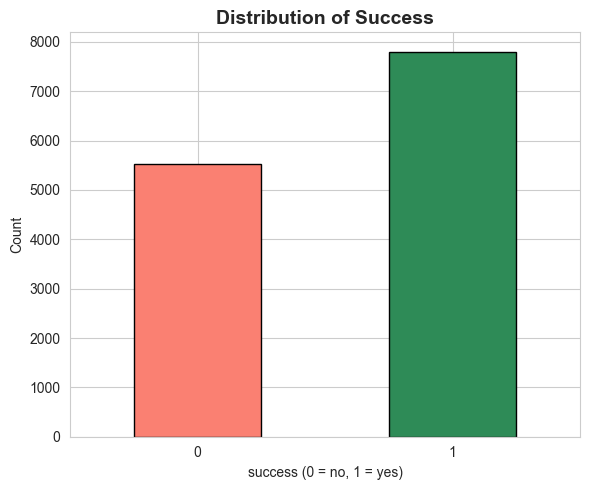

In [7]:
# Distribution of the success target

if "success" in df.columns:
    print("Value counts for success:")
    print("=" * 60)
    counts = df["success"].value_counts(dropna=False).sort_index()
    pct = df["success"].value_counts(normalize=True, dropna=False).sort_index() * 100

    summary_df = pd.DataFrame({
        "Count": counts,
        "Percentage": pct.round(2)
    })
    display(summary_df)

    plt.figure(figsize=(6, 5))
    counts.plot(kind="bar", color=["salmon", "seagreen"], edgecolor="black")
    plt.title("Distribution of Success", fontsize=14, fontweight="bold")
    plt.xlabel("success (0 = no, 1 = yes)")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
else:
    print("Column 'success' not found in the cleaned dataset.")


### 2.2 Relationship between `success` and key features

We now explore how `success` relates to a few important features already present in the cleaned dataset (e.g., total funding and region). These are exploratory visualizations to build intuition and are not final modeling features.

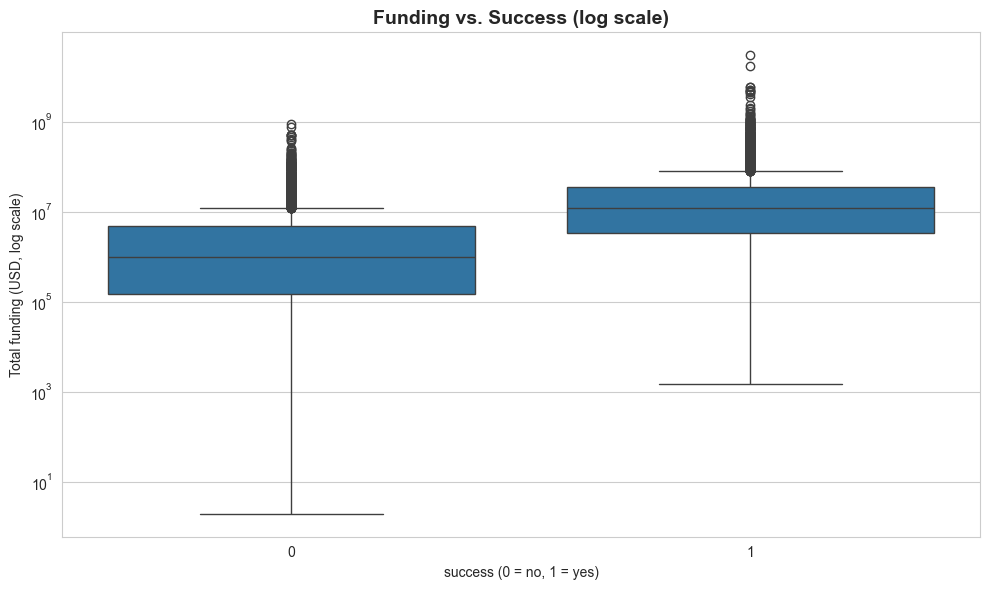

In [12]:
# Relationship between success and total funding

if {"success", "funding_total_usd"}.issubset(df.columns):
    df["funding_total_usd_num"] = pd.to_numeric(df["funding_total_usd"], errors="coerce")

    plt.figure(figsize=(10, 6))
    sns.boxplot(
        data=df.dropna(subset=["funding_total_usd_num", "success"]),
        x="success",
        y="funding_total_usd_num"
    )
    plt.yscale("log")
    plt.title("Funding vs. Success (log scale)", fontsize=14, fontweight="bold")
    plt.xlabel("success (0 = no, 1 = yes)")
    plt.ylabel("Total funding (USD, log scale)")
    plt.tight_layout()
    plt.show()
else:
    print("Required columns for funding vs success plot not available.")

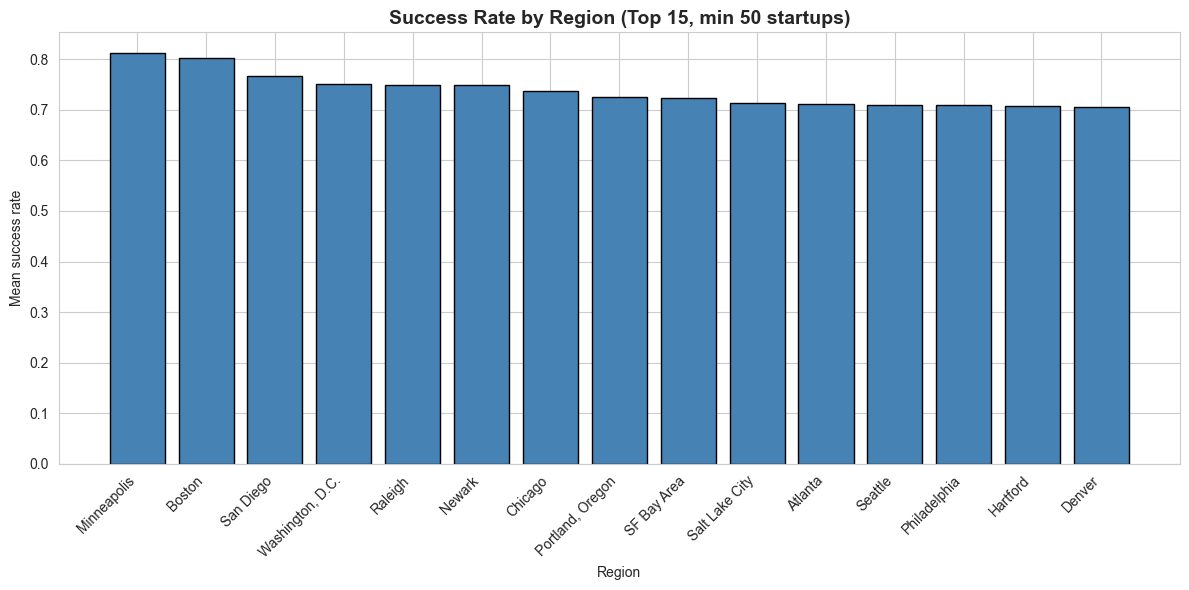

,count,success_rate
region,,
Minneapolis,80,0.812500
Boston,656,0.801829
San Diego,228,0.767544
"Washington, D.C.",221,0.751131
Raleigh,100,0.750000
Newark,144,0.750000
Chicago,190,0.736842
"Portland, Oregon",69,0.724638
SF Bay Area,2498,0.722978


In [14]:
# Relationship between success rate and region (top regions, with minimum sample size)
if {"success", "region"}.issubset(df.columns):
    MIN_STARTUPS = 50  # minimum threshold for a region to be considered

    region_stats = (
        df.dropna(subset=["region", "success"])
        .groupby("region")
        .agg(
            count=("success", "size"),
            success_rate=("success", "mean")
        )
    )

    # Keep only regions with a sufficient number of startups
    region_stats = region_stats[region_stats["count"] >= MIN_STARTUPS]

    # Select the 15 regions with the highest success rate among those remaining
    region_stats = region_stats.sort_values("success_rate", ascending=False).head(15)

    plt.figure(figsize=(12, 6))
    plt.bar(region_stats.index, region_stats["success_rate"], color="steelblue", edgecolor="black")
    plt.title("Success Rate by Region (Top 15, min 50 startups)", fontsize=14, fontweight="bold")
    plt.xlabel("Region")
    plt.ylabel("Mean success rate")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    # (optional) display the table to see count + success_rate
    display(region_stats)
else:
    print("Required columns for region vs success plot not available.")


## 3. Notes

- All analyses in this notebook are based on the cleaned dataset `startups_clean.csv` produced by the preprocessing pipeline.
- The primary target for supervised learning is the binary variable `success` defined as: 1 if a startup either survives at least 5 years or has an exit event (`acquired` or `ipo`), and 0 otherwise.
- Additional descriptive plots of features such as `status`, funding, geography, etc. can be added on top of this foundation without changing the target definition.